# Werkskapazität vs. Durchsatz: Zweidimensionale Portfolioanalyse mit PROC SGPLOT

## Zusammenfassung

Ein Produktionsportfolio in der diskreten Fertigung hat zwei Kennzahlen, die für jede Produktlinie gleichzeitig zählen: **wie viel Maschinenkapazität sie verbraucht** und **wie viel guten Output sie tatsächlich liefert**. Ein eindimensionales Balkendiagramm kann nur eine davon zeigen. Dieses Notebook visualisiert beide zusammen mit `PROC SGPLOT`, wobei ein **Blasendiagramm** die zentrale Ansicht bildet — jede Linie wird nach Kapazität (x) und Durchsatz (y) positioniert, wobei die Blasengröße ihre Produktivitätsrate (Einheiten pro Maschinenstunde) codiert. Linien, die unten rechts liegen (viel Kapazität, wenig Output), sind Kapazitätssenken; Linien, die oben links mit einer großen Blase liegen, sind ertragsstark. Eine gruppierte Balkenansicht zerlegt anschließend den Durchsatz nach Werk, und ein Produktivitätsranking bestätigt die Lücke.

Anhand der real ausgeführten Ausgabe (acht Produktlinien über drei Werke, 100 aggregierte Schichtläufe zu 24 Linie-Werk-Zellen) zeigt die Analyse, dass **Guss** die klarste Kapazitätssenke des Portfolios ist (14,3 gute Einheiten pro Maschinenstunde — sie beansprucht 10,1 % der Gesamtkapazität, liefert aber nur 3,2 % der guten Einheiten), während **Verpackung** die ertragsstärkste Linie ist (119,2 Einheiten pro Stunde — 9,1 % der Kapazität liefern 23,8 % des Outputs). Über die Werke hinweg läuft **Stuttgart** mit 49,9 Einheiten/Stunde am heißesten und **Monterrey** mit 41,6 am kühlsten.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Synthetische Schicht-Produktionsläufe über 8 Produktlinien, 3 Werke und 3 Schichten — geplante Maschinenstunden, Laufstunden, Ausfallzeit, Brutto-/Ausschuss-/Guteinheiten (auf 100 Beobachtungen begrenzt im nicht lizenzierten Modus) | 100 |
| WORK.LINE_CAPACITY | Aggregierte Zusammenfassung je Produktlinie und Werk: Gesamtkapazitätsstunden (x), produzierte gute Einheiten (y) und Ausbeute-% der akzeptierten Einheiten | 24 |

*Alle Daten sind synthetisch und werden im Notebook mit einem festen Seed erzeugt — keine externen Dateien, kein Netzwerk.*

# Werkskapazität-vs-Durchsatz-Analyse

**Domäne:** Diskrete Fertigung — Betrieb / Industrietechnik

**Prozedur:** `PROC SGPLOT` (ODS Statistical Graphics)

Ein herkömmliches Balkendiagramm zeigt eine einzelne Kennzahl pro Kategorie. Um ein Produktionsportfolio auf **zwei** numerischen Dimensionen gleichzeitig zu vergleichen — *wie viel Kapazität jede Produktlinie verbraucht* gegenüber *wie viel Output sie tatsächlich liefert* — brauchen wir einen Plot, der beide auf derselben Fläche platziert. Die `BUBBLE`-Anweisung von `PROC SGPLOT` tut genau das: Sie positioniert jede Linie nach Kapazität (x) und guten Einheiten (y) und lässt eine dritte Kennzahl, die Produktivitätsrate, die Blasengröße bestimmen. Eine Linie, die weit rechts, aber niedrig liegt, ist eine Kapazitätssenke; eine Linie, die hoch und links mit einer dicken Blase liegt, ist eine ertragsstarke Linie, die es zu schützen gilt. Dieses Notebook baut einen realistischen synthetischen Produktionsdatensatz auf und steuert SGPLOT durch ein Blasendiagramm, ein werksgruppiertes Balkendiagramm, ein Einzelwerk-Drilldown und einen nebeneinandergestellten geclusterten Werksvergleich.

> **Ein Hinweis zu PROC GAREABAR.** Der klassische SAS/GRAPH-Weg, zwei Dimensionen pro *Balken* zu codieren, ist `PROC GAREABAR` (ein reines ActiveX-Flächenbalkendiagramm, bei dem die Balkenbreite eine Variable und die Höhe eine andere codiert). GAREABAR ist **in diesem Jenner-Build noch nicht implementiert** — die Lücke wird durch den gebankten Test `tests/400996_nb_gareabar_unimplemented` nachverfolgt. Dieses Notebook erreicht dasselbe analytische Ziel mit dem vollständig unterstützten `PROC SGPLOT`, dessen Blasen- und Gruppenbalkenansichten dieselbe Kapazität-vs-Durchsatz-Geschichte vermitteln.

## 1. Erzeugung synthetischer Produktionsdaten

Wir simulieren sechs Wochen Schicht-Produktionsläufe für ein dreiwerkiges Fertigungsnetzwerk. Jede Produktlinie hat eine Basiszykluszeit und Ausschussrate; der Durchsatz wird von geplanten Maschinenstunden, linienspezifischer Effizienz und zufälliger Ausfallzeit angetrieben. `call streaminit` fixiert den Seed, sodass das Notebook vollständig reproduzierbar ist — keine externen Dateien, kein Netzwerk.

In [1]:
/* --------------------------------------------------------
   Synthetische Schicht-Produktionslaeufe
   8 Produktlinien x 3 Werke x 3 Schichten x ~10 Tage
   Breitenvariable = geplante Maschinenstunden (Kapazitaet)
   Antwort         = produzierte gute Einheiten (Durchsatz)
   -------------------------------------------------------- */
DATEN work.production_runs;
    AUFRUFEN streaminit(20260531);
    LÄNGE product_line $18 plant $12 shift $8;

    /* Produktlinienname je Index -- als direkte IF/ELSE-Zuweisung statt
       _temporary_-Array, weil ein dollar-breites _temporary_-Array mit
       nicht-ASCII-Werten (z.B. "Schweißen") auf eine inkonsistent
       kuerzere Byte-Laenge abgeschnitten wird */
    /* nominal produzierte Einheiten pro Maschinenstunde, je Linie */
    FELD line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* Basis-Ausschussanteil je Linie */
    FELD line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    FELD plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* Werks-Effizienzmultiplikator */
    FELD plant_eff[3] _temporary_ (1.00 0.92 1.08);
    /* Schicht-Effizienzmultiplikator (Schichtname je Index: siehe
       IF/ELSE-Zuweisung unten, aus demselben Grund wie product_line) */
    FELD shift_eff[3] _temporary_ (1.00 0.95 0.88);

    AUSFÜHRUNG day = 1 BIS 10;
        AUSFÜHRUNG li = 1 BIS 8;
            AUSFÜHRUNG pi = 1 BIS 3;
                AUSFÜHRUNG si = 1 BIS 3;
                    WENN      li = 1 DANN product_line = 'Stanzen';
                    SONST WENN li = 2 DANN product_line = 'Schweißen';
                    SONST WENN li = 3 DANN product_line = 'Zerspanung';
                    SONST WENN li = 4 DANN product_line = 'Guss';
                    SONST WENN li = 5 DANN product_line = 'Spritzguss';
                    SONST WENN li = 6 DANN product_line = 'Montage';
                    SONST WENN li = 7 DANN product_line = 'Endbearbeitung';
                    SONST                product_line = 'Verpackung';

                    plant        = plant_names[pi];

                    WENN      si = 1 DANN shift = 'Tag';
                    SONST WENN si = 2 DANN shift = 'Spät';
                    SONST                shift = 'Nacht';

                    /* geplante Maschinenstunden fuer die Schicht */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* ungeplante Ausfallzeit zehrt an der Kapazitaet */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* effektive Durchsatzrate mit Rauschen */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    AUSGABE;
                ENDE;
            ENDE;
        ENDE;
    ENDE;
    BEHALTEN run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.production_runs(obs=8) noobs;
    BEZEICHNUNG product_line="Produktlinie" plant="Werk" shift="Schicht"
          sched_hours="Geplante Maschinenstunden" run_hours="Laufstunden"
          downtime_hours="Ausfallzeit (Std.)" gross_units="Bruttoeinheiten"
          scrap_units="Ausschusseinheiten" good_units="Gute Einheiten"
          run_date="Datum";
    TITEL "Stichprobe synthetischer Schicht-Produktionsläufe";
AUSFÜHREN;
TITEL;

                                   Stichprobe synthetischer Schicht-Produktionsläufe                                    

    Datum  Produktlinie       Werk  Schicht  Geplante Maschinenstunden  Laufstunden  Ausfallzeit (Std.)  Bruttoeinheiten  Ausschusseinheiten  Gute Einheiten
05JAN2026  Stanzen       Detroit    Tag                            7.8          6.7                 1.1              306                  14             292
05JAN2026  Stanzen       Detroit    Spät                           6.8          6.5                 0.3              259                  12             247
05JAN2026  Stanzen       Detroit    Nacht                            8          7.6                 0.4              269                  11             258
05JAN2026  Stanzen       Monterrey  Tag                            7.9          6.8                 1.1              283                  12             271
05JAN2026  Stanzen       Monterrey  Spät                           7.5          6.9          


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.22 seconds
  cpu   0.22 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Aggregation auf Linien- und Werksebene

Die Plots vergleichen einen Punkt pro Kategorie, daher rollen wir die Schichtdetails zu einer Zusammenfassung je Produktlinie und Werk auf. `total_capacity` (Summe der geplanten Maschinenstunden) wird die **x**-Dimension, `good_units` (Summe des akzeptierten Outputs) die **y**-Dimension, und `units_per_hr` (gute Einheiten ÷ Kapazitätsstunden) die Produktivitätsrate, die die Blasengröße bestimmt. Wir behalten `plant`, damit es später als Gruppierungsvariable dienen kann. Wir bauen außerdem ein Linien-Rollup (über alle Werke) für das Portfolio-Blasendiagramm.

In [2]:
/* --------------------------------------------------------
   Aggregation auf product_line x plant
   total_capacity -> x (Kapazitaetsstunden)
   good_units     -> y (Durchsatz)
   units_per_hr   -> Blasengroesse (Produktivitaet)
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.production_runs NOPRINT NWAY;
    KLASSE product_line plant;
    VAR sched_hours good_units scrap_units;
    AUSGABE out=work.line_capacity(ENTFERNEN=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
AUSFÜHREN;

DATEN work.line_capacity;
    FESTLEGEN work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=work.line_capacity;
    NACH product_line plant;
AUSFÜHREN;

/* Linienebenen-Rollup (ueber alle drei Werke) fuer die Portfolioansicht */
PROZEDUR MITTELWERTE DATEN=work.line_capacity NOPRINT NWAY;
    KLASSE product_line;
    VAR total_capacity good_units;
    AUSGABE out=work.line_total(ENTFERNEN=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
AUSFÜHREN;

DATEN work.line_total;
    FESTLEGEN work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=work.line_total;
    NACH units_per_hr;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.line_total noobs;
    VAR product_line total_capacity good_units units_per_hr;
    BEZEICHNUNG product_line="Produktlinie" total_capacity="Gesamtkapazität (Std.)"
          good_units="Gute Einheiten" units_per_hr="Einheiten pro Stunde";
    TITEL "Portfolio-Linien gereiht nach Produktivität (gute Einheiten pro Maschinenstunde)";
AUSFÜHREN;
TITEL;

                    Portfolio-Linien gereiht nach Produktivität (gute Einheiten pro Maschinenstunde)                    

  Produktlinie   Gesamtkapazität (Std.)  Gute Einheiten  Einheiten pro Stunde
Guss                               73.4            1050                  14.3
Schweißen                         130.8            3038                  23.2
Zerspanung                        128.9            3762                  29.2
Stanzen                           130.7            4713                  36.1
Spritzguss                         66.2            3430                  51.8
Montage                            67.3            4289                  63.7
Endbearbeitung                     64.6            4927                  76.3
Verpackung                         65.9            7855                 119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Öffnen des ODS-Graphics-Ziels

`PROC SGPLOT` rendert über ODS Statistical Graphics. Wir öffnen ein `ODS HTML`-Ziel, sodass jeder Plot als Bild ausgegeben wird, und schalten `ODS GRAPHICS ON`. Es ist kein spezieller Gerätetreiber erforderlich — SGPLOT ist geräteunabhängig, im Gegensatz zu den reinen ActiveX-SAS/GRAPH-Prozeduren.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Portfolio-Blasendiagramm — Kapazität vs. Durchsatz

Die zentrale Ansicht: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Jede Produktlinie ist eine Blase, positioniert nach Gesamtkapazitätsstunden (x) und gesamten guten Einheiten (y), wobei die Blasenfläche auf ihre Produktivitätsrate skaliert ist. `DATALABEL=` druckt den Linienname neben jede Blase. Dies ist der zweidimensionale Vergleich, den ein Werksleiter sehen möchte — Kapazitätssenken fallen nach **unten rechts** (viele Stunden, wenig Output, kleine Blase); ertragsstarke Linien steigen nach **oben links** (wenig Stunden, viel Output, große Blase).

                                     Produktionsportfolio - Kapazität vs. Durchsatz                                     
                 x = geplante Maschinenstunden; y = gute Einheiten; Blasengröße = Einheiten pro Stunde                  


Unten rechts = Kapazitätssenke; oben links mit großer Blase = ertragsstarke Linie.



NOTE: Option TITLE changed to Produktionsportfolio - Kapazität vs. Durchsatz.
NOTE: Option TITLE2 changed to x = geplante Maschinenstunden; y = gute Einheiten; Blasengröße = Einheiten pro Stunde.
NOTE: Option FOOTNOTE changed to Unten rechts = Kapazitätssenke; oben links mit großer Blase = ertragsstarke Linie..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


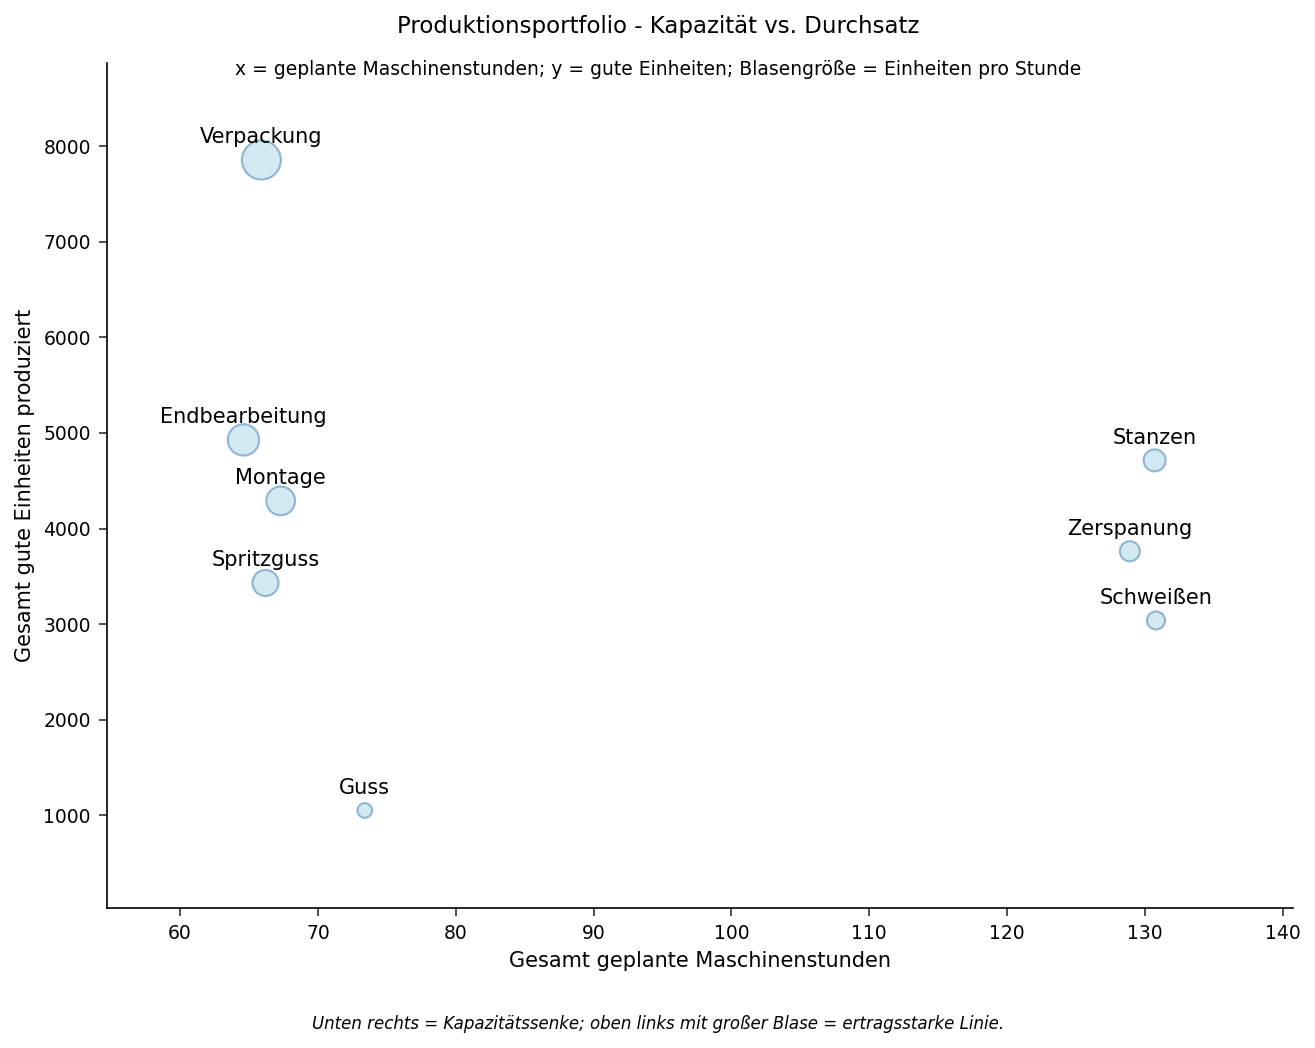

In [4]:
TITEL "Produktionsportfolio - Kapazität vs. Durchsatz";
title2 "x = geplante Maschinenstunden; y = gute Einheiten; Blasengröße = Einheiten pro Stunde";
footnote JUSTIFY=LEFT
    "Unten rechts = Kapazitätssenke; oben links mit großer Blase = ertragsstarke Linie.";

PROZEDUR SGPLOT DATEN=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS BEZEICHNUNG="Gesamt geplante Maschinenstunden";
    YAXIS BEZEICHNUNG="Gesamt gute Einheiten produziert";
AUSFÜHREN;

TITEL; title2; footnote;

## 5. Durchsatz nach Linie, aufgeschlüsselt nach Werk

Um zu sehen, wie sich der Output jeder Linie über die drei Werke verteilt, stapelt ein `VBAR product_line / response=good_units group=plant`-Diagramm die Werksbeiträge innerhalb jedes Balkens. Dies ist die Segmentierungsansicht: Sie zeigt sowohl die Gesamthöhe (gute Einheiten pro Linie) als auch den Werksmix innerhalb jedes Balkens, sodass Sie Linien erkennen können, bei denen ein Werk dominiert.

                                 Gute Einheiten nach Produktlinie, gestapelt nach Werk                                  
                               Balkenhöhe = gute Einheiten gesamt; Segmente = Werksanteil                               




NOTE: Option TITLE changed to Gute Einheiten nach Produktlinie, gestapelt nach Werk.
NOTE: Option TITLE2 changed to Balkenhöhe = gute Einheiten gesamt; Segmente = Werksanteil.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


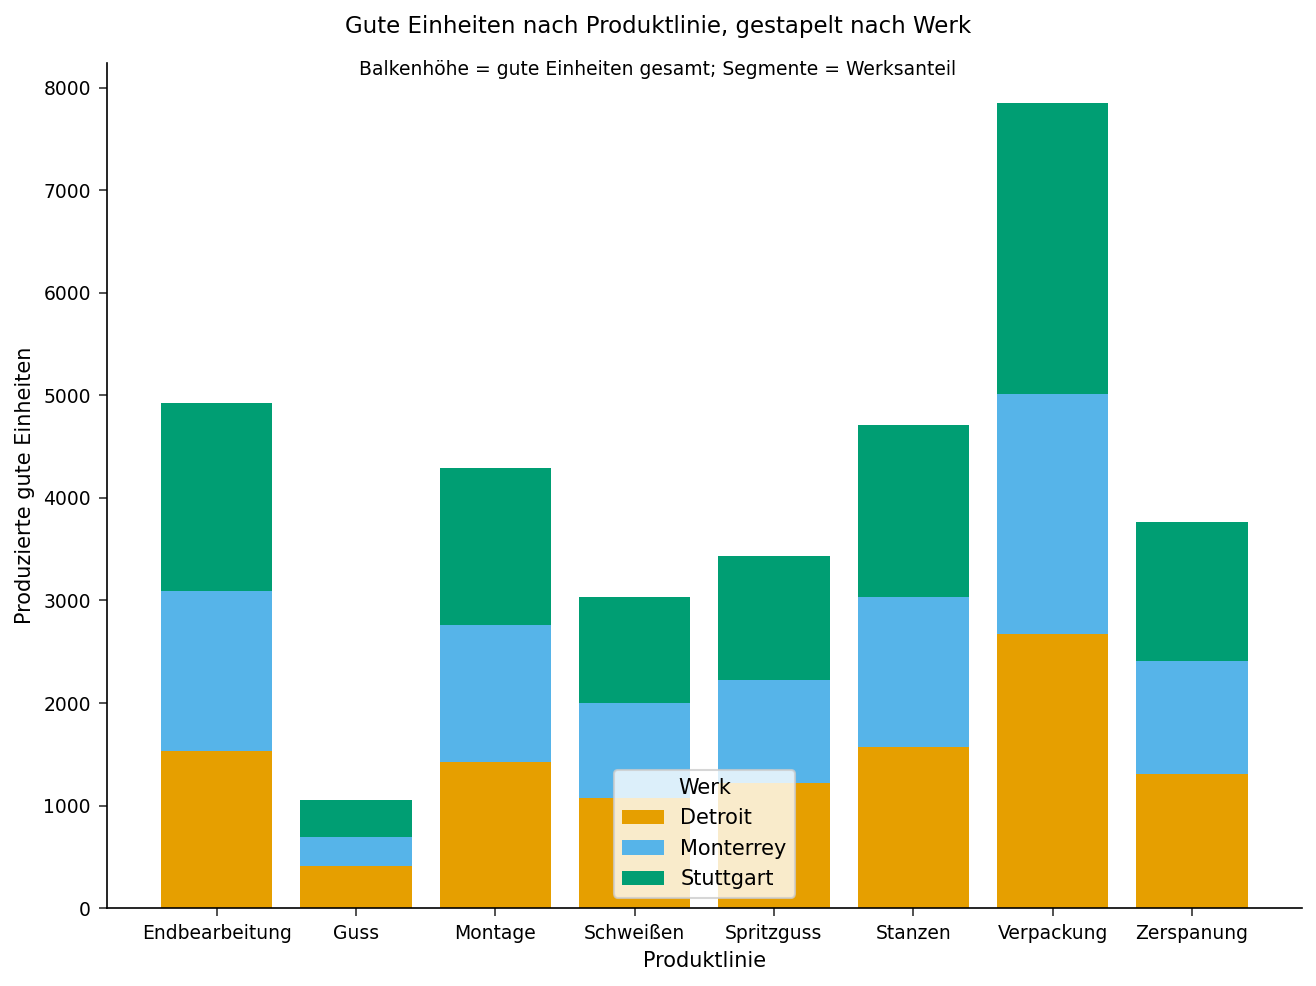

In [5]:
TITEL "Gute Einheiten nach Produktlinie, gestapelt nach Werk";
title2 "Balkenhöhe = gute Einheiten gesamt; Segmente = Werksanteil";

PROZEDUR SGPLOT DATEN=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS BEZEICHNUNG="Produktlinie" fitpolicy=ROTATE;
    YAXIS BEZEICHNUNG="Produzierte gute Einheiten";
    keylegend / TITEL="Werk" position=bottom;
AUSFÜHREN;

TITEL; title2;

## 6. Produktivitäts-Drilldown für ein einzelnes Werk (WHERE)

Horizontale Balken (`HBAR`) eignen sich für lange Produktlinienbezeichnungen. Eine `WHERE`-Klausel filtert auf das Werk Stuttgart, und die Balken werden für `units_per_hr` gezeichnet, sodass das Diagramm Stuttgarts Linien nach Produktivität reiht. Da die Eingabe aufsteigend nach Rate sortiert ist, sitzt die am wenigsten produktive Linie unten und die produktivste oben.

                                   Werk Stuttgart - Linien gereiht nach Produktivität                                   


Balkenlänge = gute Einheiten pro Maschinenstunde (Einzelwerk-Detailansicht).



NOTE: Option TITLE changed to Werk Stuttgart - Linien gereiht nach Produktivität.
NOTE: Option FOOTNOTE changed to Balkenlänge = gute Einheiten pro Maschinenstunde (Einzelwerk-Detailansicht)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


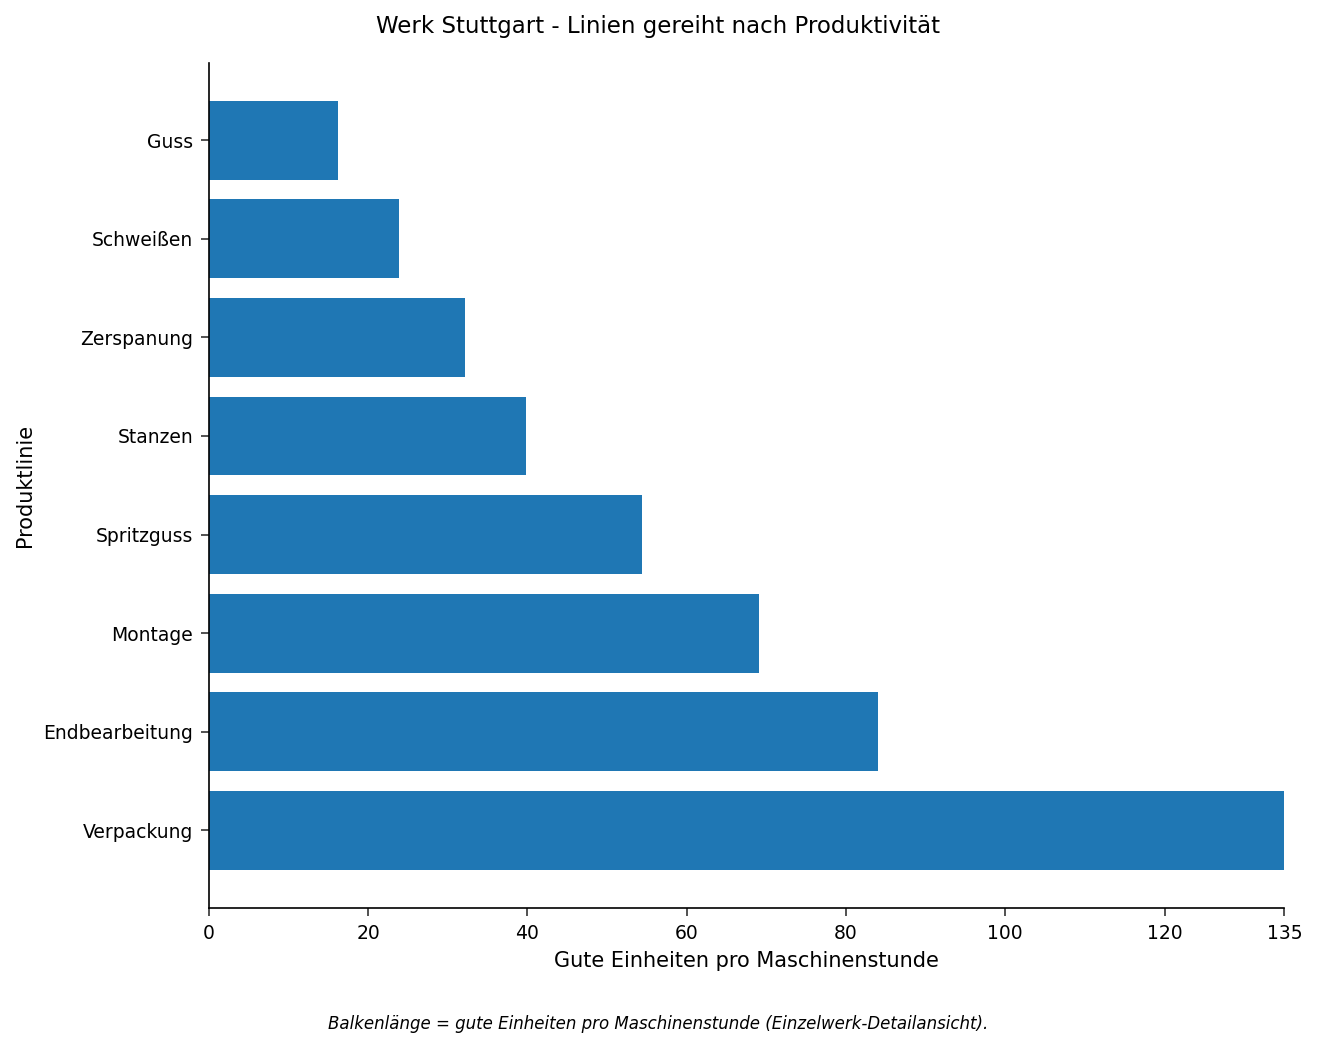

In [6]:
TITEL "Werk Stuttgart - Linien gereiht nach Produktivität";
footnote JUSTIFY=LEFT "Balkenlänge = gute Einheiten pro Maschinenstunde (Einzelwerk-Detailansicht).";

PROZEDUR SGPLOT DATEN=work.line_capacity;
    WO plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS BEZEICHNUNG="Gute Einheiten pro Maschinenstunde";
    YAXIS BEZEICHNUNG="Produktlinie";
AUSFÜHREN;

TITEL; footnote;

## 7. Werksvergleich nebeneinander (gruppierte Balken)

Um die drei Werke Linie für Linie zu vergleichen, zeichnet ein geclustertes Balkendiagramm (`GROUPDISPLAY=CLUSTER`) Detroit, Monterrey und Stuttgart als benachbarte Balken innerhalb jeder Produktlinie. Dies ist die direkte Werksvergleichsansicht: Für jede Linie können Sie ablesen, welches Werk die meisten guten Einheiten produziert hat, wodurch die Effizienzunterschiede zwischen den Werken (Stuttgart am höchsten, Monterrey am niedrigsten) direkt sichtbar werden.

                                   Gute Einheiten nach Linie und Werk - nebeneinander                                   
                          Gruppierte Balken: ein Balken pro Werk innerhalb jeder Produktlinie                           




NOTE: Option TITLE changed to Gute Einheiten nach Linie und Werk - nebeneinander.
NOTE: Option TITLE2 changed to Gruppierte Balken: ein Balken pro Werk innerhalb jeder Produktlinie.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


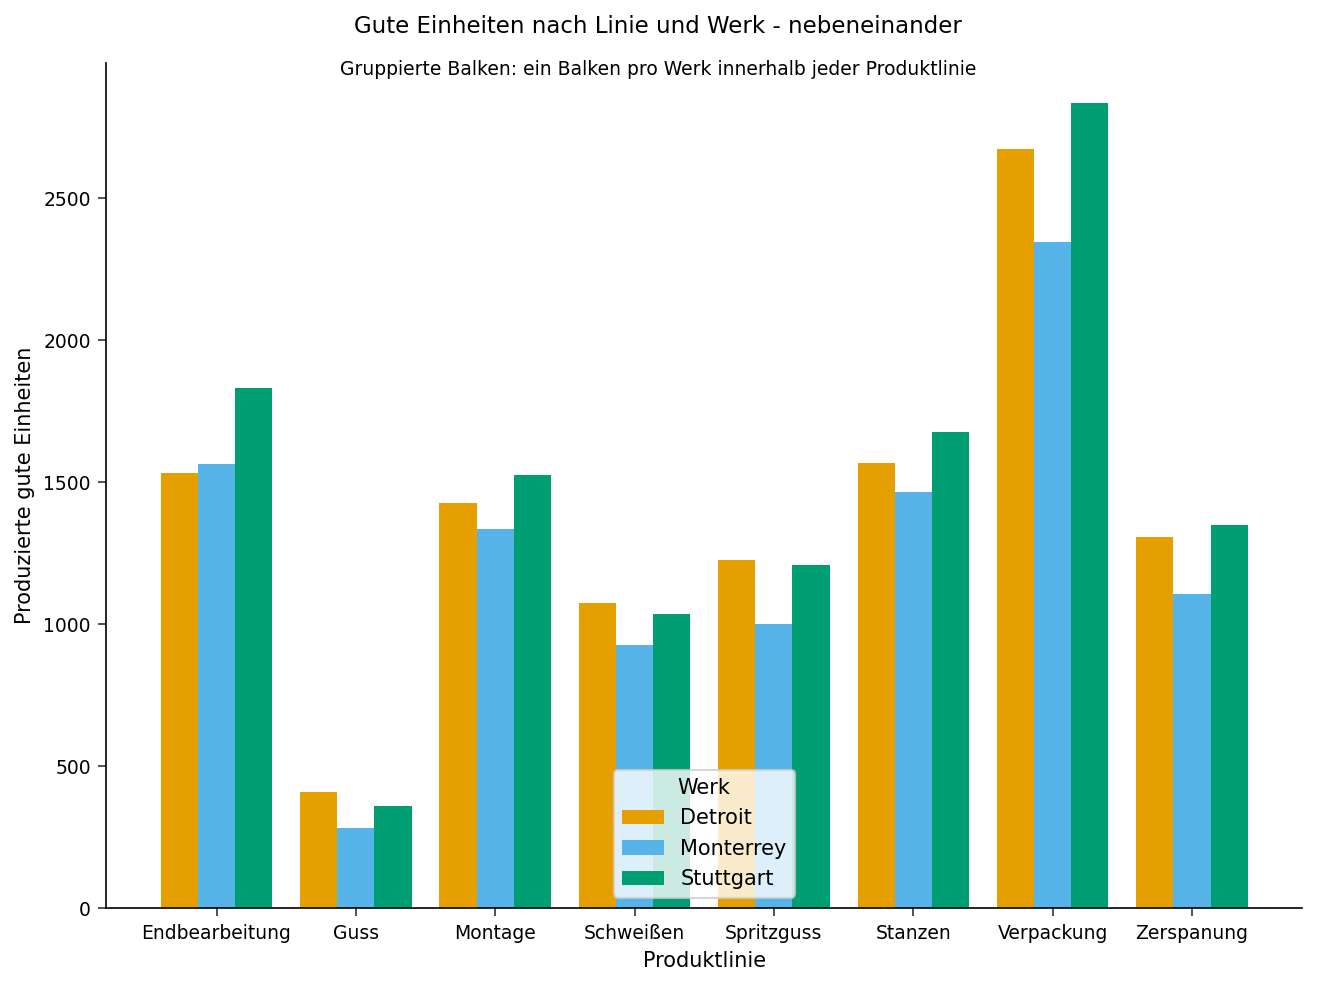

In [7]:
TITEL "Gute Einheiten nach Linie und Werk - nebeneinander";
title2 "Gruppierte Balken: ein Balken pro Werk innerhalb jeder Produktlinie";

PROZEDUR SGPLOT DATEN=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS BEZEICHNUNG="Produktlinie" fitpolicy=ROTATE;
    YAXIS BEZEICHNUNG="Produzierte gute Einheiten";
    keylegend / TITEL="Werk" position=bottom;
AUSFÜHREN;

TITEL; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Interpretation

Das gemeinsame Auftragen von Kapazität und Durchsatz auf denselben Achsen deckt einen Zusammenhang auf, den ein eindimensionales Balkendiagramm verbergen würde. **Guss** ist die klarste Kapazitätssenke des Portfolios: Im Produktivitätsranking liegt sie mit **14,3 guten Einheiten pro Maschinenstunde** ganz unten, und im Blasendiagramm fällt sie als kleine Blase nach unten links — sie beansprucht **10,1 %** der gesamten geplanten Stunden, liefert aber nur **3,2 %** der guten Einheiten (sie hat wegen ihres hohen Ausschussanteils auch die niedrigste Ausbeute, ~91 %). Sie ist die Hauptkandidatin für Zykluszeit- und Ausschussreduzierungs-Kaizen. Am anderen Ende ist **Verpackung** die ertragsstärkste Linie mit **119,2 Einheiten pro Maschinenstunde** — eine große Blase hoch auf der Durchsatzachse, die **9,1 %** der Kapazität in **23,8 %** aller guten Einheiten verwandelt; den Betrieb dieser Linie zu schützen, bringt überproportionalen Output. **Endbearbeitung** (76,3 Einheiten/Stunde) und **Montage** (63,7) folgen demselben ertragsstarken Muster.

Das Muster ist systematisch: Die vier langsamen, kapazitätshungrigen vorgelagerten Linien — Guss, Schweißen (23,2 Einheiten/Stunde), Zerspanung (29,2) und Stanzen (36,1) — verbrauchen zusammen rund **64 %** der geplanten Stunden, liefern aber nur etwa **38 %** der guten Einheiten, während die vier schnellen nachgelagerten Linien im Verhältnis zu den beanspruchten Stunden überliefern. Die nach Werk gestapelte Ansicht und die nebeneinandergestellten geclusterten Balken zeigen die dahinterliegende Werksdimension: **Stuttgart** läuft mit **49,9 guten Einheiten pro Maschinenstunde** am heißesten, **Detroit** liegt mit **44,9** in der Mitte, und **Monterrey** liegt mit **41,6** zurück — im Einklang mit Monterreys höherer modellierter Ausfallzeit. Betrieblich deutet dies darauf hin, geplante Stunden zugunsten der ertragsstarken nachgelagerten Linien umzuschichten und Monterreys Ausfallzeit gegen Stuttgarts Praktiken zu benchmarken.

*Nur synthetische Daten — die Zahlen veranschaulichen die zweidimensionale Kapazität-vs-Durchsatz-Visualisierung mit PROC SGPLOT, keine tatsächliche Werksleistung.*